# Importing Libraries

In [1]:
import pandas as pd
import numpy as np

import geopandas as gpd
import folium
from folium.plugins import HeatMap
import pydeck as pdk
import hashlib



import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from matplotlib.patches import Patch

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
from sklearn.datasets import make_blobs

from shapely import wkt

# Loading DF

In [2]:
pre_norm_df_final = pd.read_csv('..\\Data\\display_rdy_STREET_4.csv', low_memory=False)
norm_df = pd.read_csv('..\\Data\\norm_STREET_5.csv', low_memory=False)
nyc_map = gpd.read_file("..\\Data\\Modified Zip Code Tabulation Areas (MODZCTA).geojson")
streets_projected = gpd.read_file("..\\Data\\nyc_clustered_streets.gpkg")

# Clustering Hierarchical

In [3]:
# Print clustering output
def output(labels):
    labels = pd.Series(labels)
    print("The labels:\n", labels)
    print("===================")
    print("Cluster Counts:\n", labels.value_counts())


In [4]:
# Drop incident zip column
Features = norm_df.drop("Street_Name", axis=1)

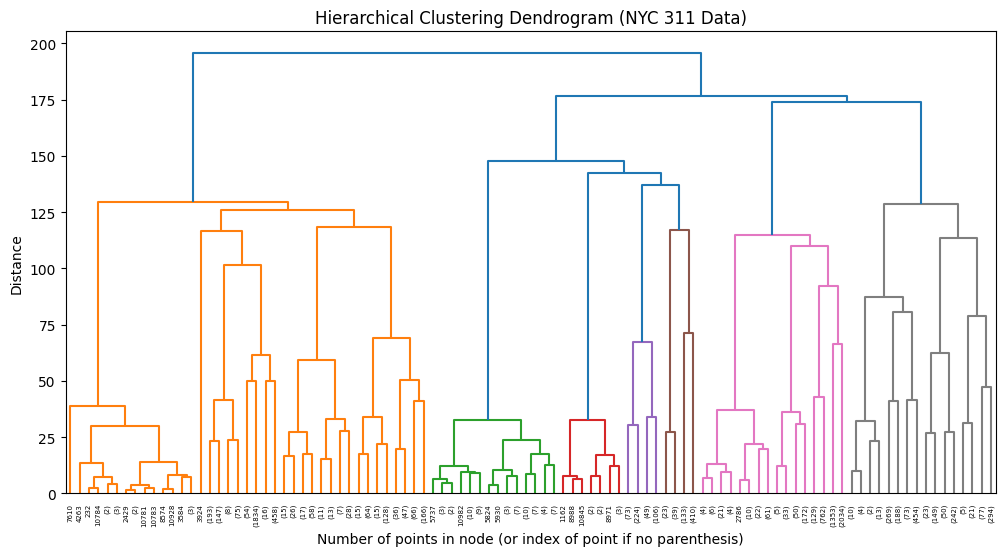

In [5]:
# Fitting the model 
agg = AgglomerativeClustering(
    distance_threshold=0,
    n_clusters=None,
    compute_distances=True
)
agg.fit(Features)

# Dendrogram plot func
def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]).astype(float)
    dendrogram(linkage_matrix, **kwargs)


# Plot the Dendrogram
plt.figure(figsize=(12, 6))
plot_dendrogram(agg, truncate_mode='level', p=6) # p is rendreing limit
plt.title("Hierarchical Clustering Dendrogram (NYC 311 Data)")
plt.xlabel("Number of points in node (or index of point if no parenthesis)")
plt.ylabel("Distance")
plt.show()


In [7]:
# Get labels
final_clustering = AgglomerativeClustering(n_clusters=10)
labels = final_clustering.fit_predict(Features)
pre_norm_df_final['Cluster'] = labels
output(labels)

The labels:
 0        4
1        8
2        3
3        1
4        3
        ..
11188    4
11189    4
11190    8
11191    3
11192    3
Length: 11193, dtype: int64
Cluster Counts:
 3    4667
4    2786
8    1013
2     861
0     712
1     605
6     452
9      66
7      20
5      11
Name: count, dtype: int64


# Draw the results on a map

In [8]:
# Define the tiny outlier clusters you want to push to the end
vc = pre_norm_df_final['Cluster'].value_counts()
outlier_clusters = singleton_labels = vc[vc == 1].index.tolist()

# Get a list of all current clusters in your dataframe, sorted numerically
current_clusters = sorted(pre_norm_df_final['Cluster'].dropna().unique())

# Separate the "main" clusters from the "outlier" clusters
main_clusters = [c for c in current_clusters if c not in outlier_clusters]
outliers_present = [c for c in outlier_clusters if c in current_clusters]

# Create a new ordered list: Main clusters first, followed by outliers at the end
new_cluster_order = main_clusters + outliers_present

# Create a mapping dictionary {old_id: new_id}
# This automatically assigns 0, 1, 2... etc.
# Your main clusters will become 0 to 10, and your outliers will become 11, 12, 13, 14.
cluster_mapping = {old_id: new_id for new_id, old_id in enumerate(new_cluster_order)}

# Let's print the mapping so you can verify it worked exactly as you wanted
print("Here is how the clusters are being renumbered:")
for old, new in cluster_mapping.items():
    print(f"Old Cluster {old} --> New Cluster {new}")

# Apply the mapping to overwrite the old numbers
pre_norm_df_final['Cluster'] = pre_norm_df_final['Cluster'].map(cluster_mapping)

Here is how the clusters are being renumbered:
Old Cluster 0 --> New Cluster 0
Old Cluster 1 --> New Cluster 1
Old Cluster 2 --> New Cluster 2
Old Cluster 3 --> New Cluster 3
Old Cluster 4 --> New Cluster 4
Old Cluster 5 --> New Cluster 5
Old Cluster 6 --> New Cluster 6
Old Cluster 7 --> New Cluster 7
Old Cluster 8 --> New Cluster 8
Old Cluster 9 --> New Cluster 9


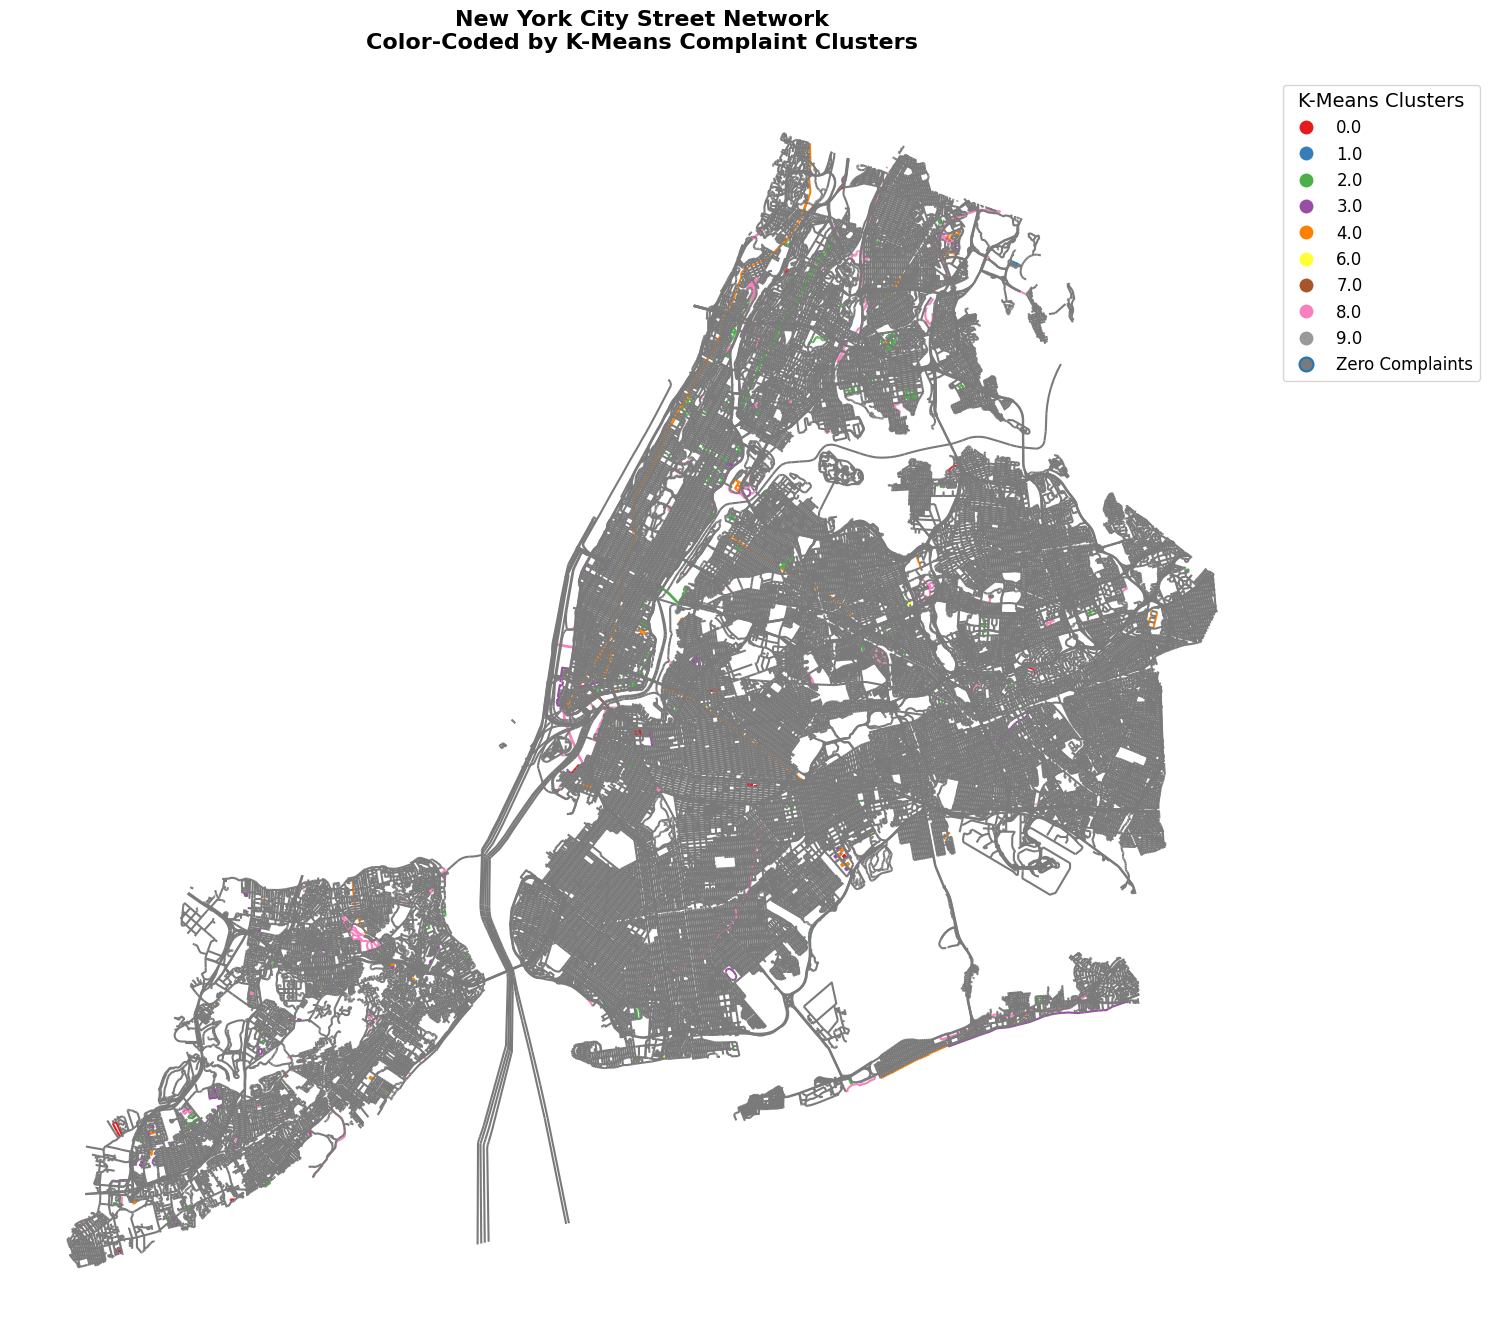

In [10]:
# 1. THE LEFT JOIN: Keep every single street
joined_map_gdf = streets_projected.merge(
    pre_norm_df_final[['Street_Name', 'Cluster']], 
    left_on='full_street_name', 
    right_on='Street_Name', 
    how='left'
)

fig, ax = plt.subplots(figsize=(15, 15))

# 2. DRAW THE MAP
joined_map_gdf.plot(
    column='Cluster',
    cmap='Set1',          
    linewidth=1.5,
    categorical=True,
    legend=True,
    ax=ax,
    # === ONLY THE EMPTY STREETS ARE BLACK ===
    missing_kwds={
        "color": "#7a7a7a",  
        "label": "Zero Complaints"
    },
    # ========================================
    legend_kwds={
        'title': 'K-Means Clusters',
        'loc': 'upper left',
        'bbox_to_anchor': (1, 1),
        'fontsize': 12,
        'title_fontsize': 14
    }
)

ax.set_axis_off()
# Title is back to default black so you can actually read it
plt.title("New York City Street Network\nColor-Coded by K-Means Complaint Clusters", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# 1. Combine your features and your new hierarchical labels
features_with_labels = Features.copy()
features_with_labels['Cluster'] = labels

# 2. Calculate the manual "centroids" (the mathematical average of each cluster)
hierarchical_centroids = features_with_labels.groupby('Cluster').mean()

# 3. Re-use our persona analysis function
def analyze_hierarchical_personas(centroid_dataframe, top_n=3):
    """
    Identifies the top N driving features for each hierarchical cluster.
    """
    print(f"--- Top {top_n} Defining 311 Complaints per Hierarchical Cluster ---\n")
    
    # Iterate through the index (which now contains the cluster numbers 0 through 9)
    for cluster_id in centroid_dataframe.index:
        
        # Isolate the current cluster's averages
        cluster_profile = centroid_dataframe.loc[cluster_id]
        
        # Sort to find the highest dominating complaints
        top_features = cluster_profile.sort_values(ascending=False).head(top_n)
        
        print(f"Cluster {cluster_id}:")
        for feature, value in top_features.items():
            print(f"  * {feature}: {value:.4f}")
            
        print("-" * 40)

# 4. Run the analysis!
analyze_hierarchical_personas(hierarchical_centroids, top_n=4)

--- Top 4 Defining 311 Complaints per Hierarchical Cluster ---

Cluster 0:
  * Trees_and_Parks_Pct: 1.6573
  * Sanitation_and_Trash_Pct: 1.1900
  * Construction_and_DOB_Pct: 0.7309
  * Other/Misc_LType_Pct: 0.5123
----------------------------------------
Cluster 1:
  * Public_Spaces_and_Outdoors_Pct: 5.6384
  * Health_and_Environmental_Safety_Pct: 3.9083
  * Weekend_Ratio: 3.8099
  * Animals_and_Pets_Pct: 2.2139
----------------------------------------
Cluster 2:
  * Commercial_and_Retail_Pct: 5.7792
  * Median_Resolution_Time: 5.2007
  * Other/Misc_CType_Pct: 4.6300
  * Infrastructure_and_Building_Components_Pct: -0.1817
----------------------------------------
Cluster 3:
  * Agency_Diversity: 0.5694
  * Total_Complaints: 0.3835
  * Night_Complaint_Pct: 0.3623
  * Vehicles_and_Parking_Pct: 0.3396
----------------------------------------
Cluster 4:
  * Taxi_and_For-Hire_Vehicles_Pct: 0.9562
  * Other/Misc_CType_Pct: 0.7915
  * Public_Order_and_Police_Pct: 0.7580
  * Street_and_Transpor